In [9]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create output directory for PDFs
OUTPUT_DIR = "EDA_Plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("CLIP DATASET - EXPLORATORY DATA ANALYSIS")
print("=" * 80)
print(f"\n✓ Output directory for plots: {OUTPUT_DIR}")

CLIP DATASET - EXPLORATORY DATA ANALYSIS

✓ Output directory for plots: EDA_Plots


In [2]:
# CELL 2: DEFINE DIRECTORY PATHS
# ============================================================================

# Define base directory
BASE_DIR = "C:\Code\AISEMPROJECT\cadenza_data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
METADATA_DIR = os.path.join(BASE_DIR, "metadata")

# Define audio directories
TRAIN_SIGNALS = os.path.join(TRAIN_DIR, "signals")
TRAIN_UNPROCESSED = os.path.join(TRAIN_DIR, "unprocessed")
VALID_SIGNALS = os.path.join(VALID_DIR, "signals")
VALID_UNPROCESSED = os.path.join(VALID_DIR, "unprocessed")

print(f"\n✓ Base Directory: {BASE_DIR}")
print(f"✓ Training Audio (Processed): {TRAIN_SIGNALS}")
print(f"✓ Training Audio (Unprocessed): {TRAIN_UNPROCESSED}")
print(f"✓ Validation Audio (Processed): {VALID_SIGNALS}")
print(f"✓ Validation Audio (Unprocessed): {VALID_UNPROCESSED}")


✓ Base Directory: C:\Code\AISEMPROJECT\cadenza_data
✓ Training Audio (Processed): C:\Code\AISEMPROJECT\cadenza_data\train\signals
✓ Training Audio (Unprocessed): C:\Code\AISEMPROJECT\cadenza_data\train\unprocessed
✓ Validation Audio (Processed): C:\Code\AISEMPROJECT\cadenza_data\valid\signals
✓ Validation Audio (Unprocessed): C:\Code\AISEMPROJECT\cadenza_data\valid\unprocessed


In [3]:
# CELL 3: LOAD METADATA (JSON FORMAT)
# ============================================================================

print("\n" + "=" * 80)
print("LOADING METADATA (JSON FORMAT)")
print("=" * 80)

metadata_df = None

try:
    # Find JSON metadata files
    metadata_files = list(Path(METADATA_DIR).glob("*.json"))
    
    if metadata_files:
        print(f"\nFound {len(metadata_files)} JSON metadata file(s):")
        for f in metadata_files:
            print(f"  - {f.name}")
        
        # Load the first JSON file
        with open(metadata_files[0], 'r') as f:
            metadata_json = json.load(f)
        
        # Convert JSON to DataFrame
        # Handle different JSON structures
        if isinstance(metadata_json, list):
            # If JSON is a list of dictionaries
            metadata_df = pd.DataFrame(metadata_json)
        elif isinstance(metadata_json, dict):
            # If JSON is a dictionary, try to convert
            # Check if it's a nested structure
            if all(isinstance(v, dict) for v in metadata_json.values()):
                # Dictionary of dictionaries - convert to DataFrame
                metadata_df = pd.DataFrame.from_dict(metadata_json, orient='index')
            else:
                # Single record
                metadata_df = pd.DataFrame([metadata_json])
        
        print(f"\n✓ Loaded metadata from: {metadata_files[0].name}")
        print(f"✓ Shape: {metadata_df.shape}")
        print(f"\nFirst few rows:")
        print(metadata_df.head())
        print(f"\nColumn names:")
        print(metadata_df.columns.tolist())
        print(f"\nData types:")
        print(metadata_df.dtypes)
        
    else:
        print("\n⚠ No JSON metadata files found in metadata directory")
        print(f"   Checked directory: {METADATA_DIR}")
        
except Exception as e:
    print(f"\n⚠ Error loading metadata: {e}")
    print(f"   Error type: {type(e).__name__}")
    metadata_df = None


LOADING METADATA (JSON FORMAT)

Found 2 JSON metadata file(s):
  - train_metadata.json
  - valid_metadata.json

✓ Loaded metadata from: train_metadata.json
✓ Shape: (8802, 7)

First few rows:
                     signal                                          prompt  \
0  c221f2084c780e8f212f4697                          cos you better hold on   
1  63de05fbfcab2d7748b83cb3                    And then lower it down again   
2  cf74c013a02d82d04254a910   the blind sleep, and the deaf and dumb sleep    
3  56f3fb4847d2c90f38e8e983  a street a couple of cars and maybe some trees   
4  b2486a8e181f84acd2db4d61                    in my mind I can see is fine   

                                   response  n_words  words_correct  \
0                                         #        5              0   
1      I don't know where it's all the same        6              1   
2  The blind sleep and the deaf under sleep        9              7   
3                                         #     

In [4]:
# CELL 4: COUNT AUDIO FILES (FLAC FORMAT)
# ============================================================================

print("\n" + "=" * 80)
print("AUDIO FILES STRUCTURE ANALYSIS (FLAC FORMAT)")
print("=" * 80)

def count_audio_files(directory):
    """Count FLAC audio files in a directory"""
    if not os.path.exists(directory):
        print(f"   ⚠ Directory does not exist: {directory}")
        return 0, []
    
    # Primary format is FLAC, but also check for other formats
    audio_extensions = ['.flac', '.wav', '.mp3', '.ogg']
    files = [f for f in os.listdir(directory) 
             if any(f.lower().endswith(ext) for ext in audio_extensions)]
    
    # Count by extension
    flac_files = [f for f in files if f.lower().endswith('.flac')]
    other_files = [f for f in files if not f.lower().endswith('.flac')]
    
    if flac_files:
        print(f"   Found {len(flac_files)} FLAC files")
    if other_files:
        print(f"   Found {len(other_files)} other audio files")
    
    return len(files), files

# Count files in each directory
print("\n📁 Training Set (Processed/Signals):")
train_signals_count, train_signals_files = count_audio_files(TRAIN_SIGNALS)

print("\n📁 Training Set (Unprocessed):")
train_unproc_count, train_unproc_files = count_audio_files(TRAIN_UNPROCESSED)

print("\n📁 Validation Set (Processed/Signals):")
valid_signals_count, valid_signals_files = count_audio_files(VALID_SIGNALS)

print("\n📁 Validation Set (Unprocessed):")
valid_unproc_count, valid_unproc_files = count_audio_files(VALID_UNPROCESSED)

print(f"\n" + "=" * 80)
print(f"📊 AUDIO FILE COUNTS SUMMARY:")
print(f"=" * 80)
print(f"  Training Set (Processed/Signals): {train_signals_count} files")
print(f"  Training Set (Unprocessed): {train_unproc_count} files")
print(f"  Validation Set (Processed/Signals): {valid_signals_count} files")
print(f"  Validation Set (Unprocessed): {valid_unproc_count} files")
print(f"  TOTAL AUDIO FILES: {train_signals_count + train_unproc_count + valid_signals_count + valid_unproc_count}")


AUDIO FILES STRUCTURE ANALYSIS (FLAC FORMAT)

📁 Training Set (Processed/Signals):
   Found 8802 FLAC files

📁 Training Set (Unprocessed):
   Found 8802 FLAC files

📁 Validation Set (Processed/Signals):
   Found 1175 FLAC files

📁 Validation Set (Unprocessed):
   Found 1175 FLAC files

📊 AUDIO FILE COUNTS SUMMARY:
  Training Set (Processed/Signals): 8802 files
  Training Set (Unprocessed): 8802 files
  Validation Set (Processed/Signals): 1175 files
  Validation Set (Unprocessed): 1175 files
  TOTAL AUDIO FILES: 19954


In [5]:
# CELL 5: ANALYZE SAMPLE AUDIO FILES (FLAC FORMAT)
# ============================================================================

print("\n" + "=" * 80)
print("DETAILED AUDIO ANALYSIS (SAMPLE FLAC FILES)")
print("=" * 80)

# Select sample files for detailed analysis
sample_files = []
if train_signals_files:
    sample_files.append(('Train-Processed', os.path.join(TRAIN_SIGNALS, train_signals_files[0])))
    print(f"✓ Selected from Train-Processed: {train_signals_files[0]}")
if train_unproc_files:
    sample_files.append(('Train-Unprocessed', os.path.join(TRAIN_UNPROCESSED, train_unproc_files[0])))
    print(f"✓ Selected from Train-Unprocessed: {train_unproc_files[0]}")

def analyze_audio(file_path):
    """Analyze a single FLAC audio file"""
    try:
        # Load FLAC file with librosa
        y, sr = librosa.load(file_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        
        # Audio statistics
        rms = librosa.feature.rms(y=y)[0]
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
        
        return {
            'duration': duration,
            'sample_rate': sr,
            'samples': len(y),
            'rms_mean': np.mean(rms),
            'rms_std': np.std(rms),
            'zcr_mean': np.mean(zcr),
            'spectral_centroid_mean': np.mean(spectral_centroid),
            'spectral_rolloff_mean': np.mean(spectral_rolloff),
            'audio_data': y,
            'sr': sr
        }
    except Exception as e:
        print(f"  ⚠ Error analyzing {file_path}: {e}")
        return None

# Analyze sample files
audio_stats = []
print("\n" + "-" * 80)
for label, file_path in sample_files:
    print(f"\n📁 Analyzing: {label}")
    print(f"   File: {os.path.basename(file_path)}")
    print(f"   Format: {os.path.splitext(file_path)[1].upper()}")
    
    stats = analyze_audio(file_path)
    if stats:
        audio_stats.append((label, stats))
        print(f"   ✓ Duration: {stats['duration']:.2f} seconds")
        print(f"   ✓ Sample Rate: {stats['sample_rate']} Hz")
        print(f"   ✓ Total Samples: {stats['samples']:,}")
        print(f"   ✓ RMS Energy (mean): {stats['rms_mean']:.4f}")
        print(f"   ✓ Zero Crossing Rate (mean): {stats['zcr_mean']:.4f}")
        print(f"   ✓ Spectral Centroid (mean): {stats['spectral_centroid_mean']:.2f} Hz")
        print(f"   ✓ Spectral Rolloff (mean): {stats['spectral_rolloff_mean']:.2f} Hz")

# ============================================================================


DETAILED AUDIO ANALYSIS (SAMPLE FLAC FILES)
✓ Selected from Train-Processed: 000298fd608a8aa71da2b59c.flac
✓ Selected from Train-Unprocessed: 000298fd608a8aa71da2b59c_unproc.flac

--------------------------------------------------------------------------------

📁 Analyzing: Train-Processed
   File: 000298fd608a8aa71da2b59c.flac
   Format: .FLAC
   ✓ Duration: 3.43 seconds
   ✓ Sample Rate: 44100 Hz
   ✓ Total Samples: 151,424
   ✓ RMS Energy (mean): 0.0159
   ✓ Zero Crossing Rate (mean): 0.0364
   ✓ Spectral Centroid (mean): 1231.33 Hz
   ✓ Spectral Rolloff (mean): 1792.13 Hz

📁 Analyzing: Train-Unprocessed
   File: 000298fd608a8aa71da2b59c_unproc.flac
   Format: .FLAC
   ✓ Duration: 3.43 seconds
   ✓ Sample Rate: 44100 Hz
   ✓ Total Samples: 151,208
   ✓ RMS Energy (mean): 0.0182
   ✓ Zero Crossing Rate (mean): 0.0706
   ✓ Spectral Centroid (mean): 2437.38 Hz
   ✓ Spectral Rolloff (mean): 4587.45 Hz


In [6]:
# CELL 6: COLLECT DURATION STATISTICS (FLAC FILES)
# ============================================================================

print("\n" + "=" * 80)
print("COLLECTING DURATION STATISTICS (ALL FLAC FILES)")
print("=" * 80)

def collect_durations(directory, max_files=100):
    """Collect duration statistics from FLAC audio files"""
    if not os.path.exists(directory):
        print(f"  ⚠ Directory does not exist: {directory}")
        return []
    
    # Find FLAC files (and other audio formats as backup)
    audio_files = [os.path.join(directory, f) for f in os.listdir(directory) 
                   if f.lower().endswith(('.flac', '.wav', '.mp3', '.ogg'))]
    
    if not audio_files:
        print(f"  ⚠ No audio files found in {os.path.basename(directory)}")
        return []
    
    durations = []
    print(f"\n  Processing up to {min(max_files, len(audio_files))} files from {os.path.basename(directory)}...")
    print(f"  Total available files: {len(audio_files)}")
    
    for i, file_path in enumerate(audio_files[:max_files]):
        try:
            duration = librosa.get_duration(path=file_path)
            durations.append(duration)
            if (i + 1) % 20 == 0:
                print(f"    ✓ Processed {i + 1}/{min(max_files, len(audio_files))} files...")
        except Exception as e:
            print(f"    ⚠ Error with {os.path.basename(file_path)}: {e}")
    
    print(f"  ✓ Successfully processed {len(durations)} files")
    return durations

# Collect durations (limiting to first 100 files per directory for speed)
train_proc_durations = collect_durations(TRAIN_SIGNALS, max_files=100)
train_unproc_durations = collect_durations(TRAIN_UNPROCESSED, max_files=100)
valid_proc_durations = collect_durations(VALID_SIGNALS, max_files=100)
valid_unproc_durations = collect_durations(VALID_UNPROCESSED, max_files=100)

all_durations = train_proc_durations + train_unproc_durations + valid_proc_durations + valid_unproc_durations

if all_durations:
    print(f"\n" + "=" * 80)
    print(f"📊 DURATION STATISTICS (ACROSS ALL PROCESSED FILES):")
    print(f"=" * 80)
    print(f"   Total files analyzed: {len(all_durations)}")
    print(f"   Mean Duration: {np.mean(all_durations):.2f} seconds")
    print(f"   Median Duration: {np.median(all_durations):.2f} seconds")
    print(f"   Std Duration: {np.std(all_durations):.2f} seconds")
    print(f"   Min Duration: {np.min(all_durations):.2f} seconds")
    print(f"   Max Duration: {np.max(all_durations):.2f} seconds")
else:
    print("\n⚠ No duration data collected. Please check if audio files exist.")

# ============================================================================


COLLECTING DURATION STATISTICS (ALL FLAC FILES)

  Processing up to 100 files from signals...
  Total available files: 8802
    ✓ Processed 20/100 files...
    ✓ Processed 40/100 files...
    ✓ Processed 60/100 files...
    ✓ Processed 80/100 files...
    ✓ Processed 100/100 files...
  ✓ Successfully processed 100 files

  Processing up to 100 files from unprocessed...
  Total available files: 8802
    ✓ Processed 20/100 files...
    ✓ Processed 40/100 files...
    ✓ Processed 60/100 files...
    ✓ Processed 80/100 files...
    ✓ Processed 100/100 files...
  ✓ Successfully processed 100 files

  Processing up to 100 files from signals...
  Total available files: 1175
    ✓ Processed 20/100 files...
    ✓ Processed 40/100 files...
    ✓ Processed 60/100 files...
    ✓ Processed 80/100 files...
    ✓ Processed 100/100 files...
  ✓ Successfully processed 100 files

  Processing up to 100 files from unprocessed...
  Total available files: 1175
    ✓ Processed 20/100 files...
    ✓ Process


GENERATING PLOT 1: WAVEFORMS
✓ Saved: EDA_Plots\01_Waveforms.pdf


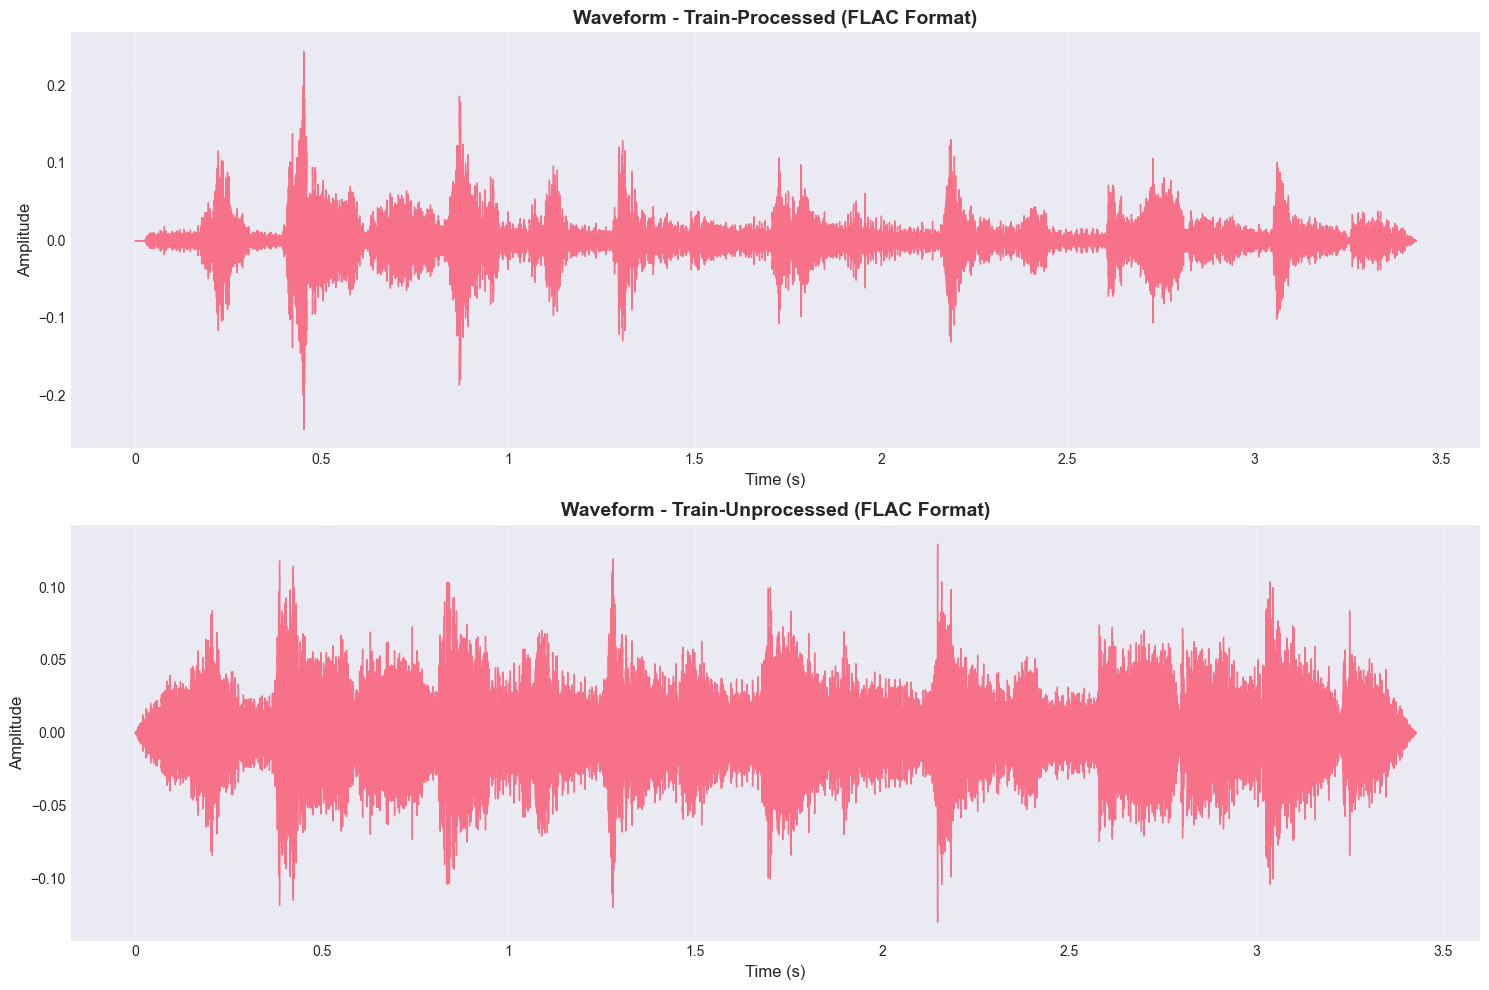

In [7]:
# CELL 7: PLOT 1 - WAVEFORMS
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING PLOT 1: WAVEFORMS")
print("=" * 80)

if audio_stats:
    fig, axes = plt.subplots(len(audio_stats), 1, figsize=(15, 5*len(audio_stats)))
    if len(audio_stats) == 1:
        axes = [axes]
    
    for idx, (label, stats) in enumerate(audio_stats):
        librosa.display.waveshow(stats['audio_data'], sr=stats['sr'], ax=axes[idx])
        axes[idx].set_title(f'Waveform - {label} (FLAC Format)', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Time (s)', fontsize=12)
        axes[idx].set_ylabel('Amplitude', fontsize=12)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, "01_Waveforms.pdf")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()
else:
    print("⚠ No audio data available for waveform plotting")


GENERATING PLOT 2: SPECTROGRAMS
✓ Saved: EDA_Plots\02_Spectrograms.pdf


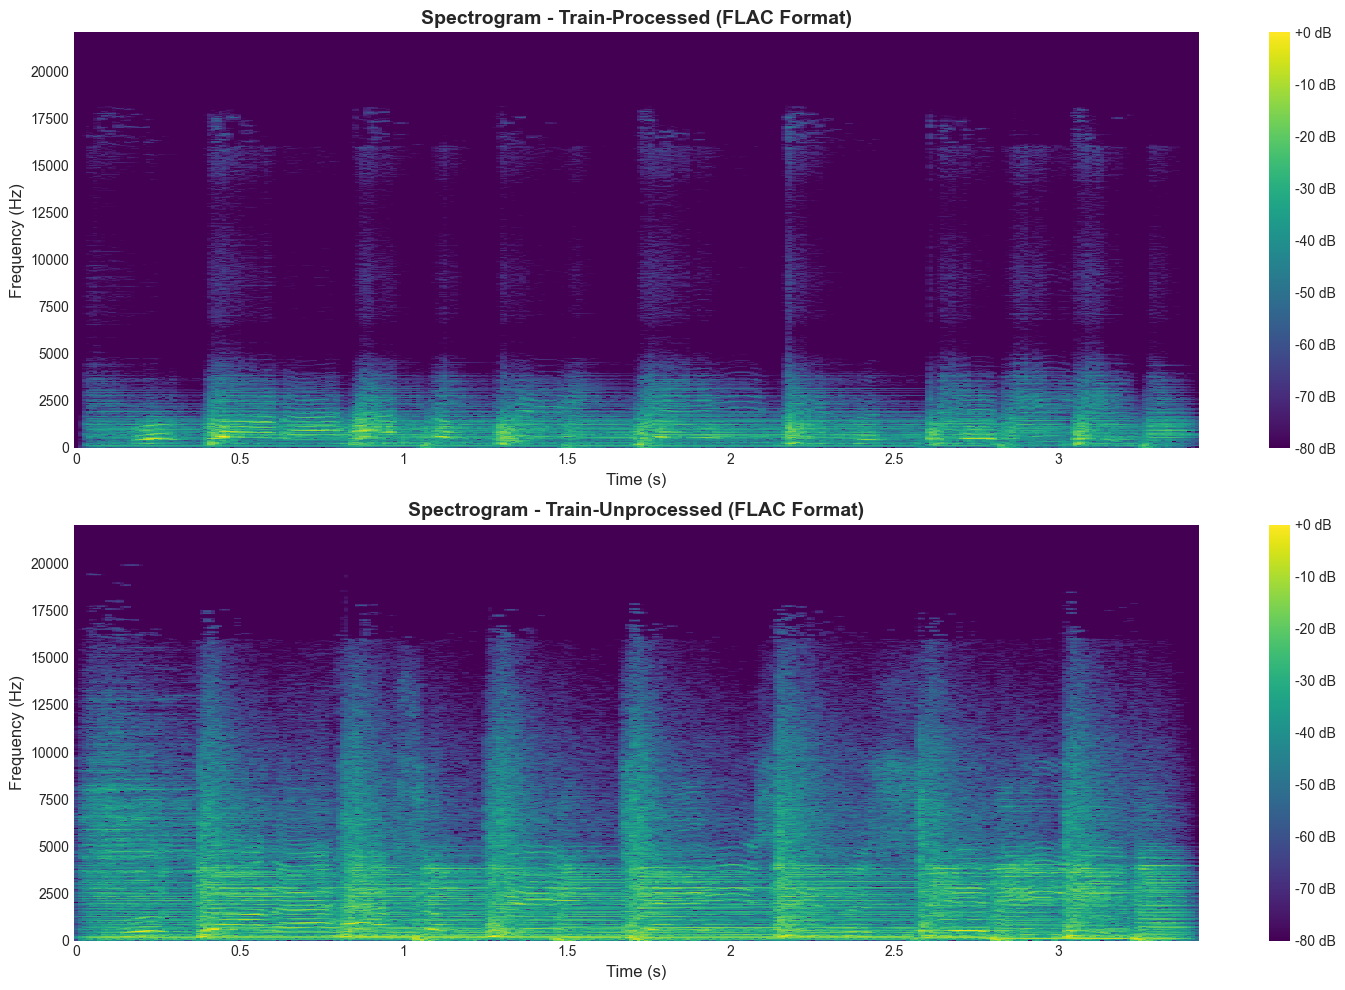

In [8]:
# CELL 8: PLOT 2 - SPECTROGRAMS
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING PLOT 2: SPECTROGRAMS")
print("=" * 80)

if audio_stats:
    fig, axes = plt.subplots(len(audio_stats), 1, figsize=(15, 5*len(audio_stats)))
    if len(audio_stats) == 1:
        axes = [axes]
    
    for idx, (label, stats) in enumerate(audio_stats):
        D = librosa.amplitude_to_db(np.abs(librosa.stft(stats['audio_data'])), ref=np.max)
        img = librosa.display.specshow(D, sr=stats['sr'], x_axis='time', y_axis='hz', 
                                      ax=axes[idx], cmap='viridis')
        axes[idx].set_title(f'Spectrogram - {label} (FLAC Format)', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Time (s)', fontsize=12)
        axes[idx].set_ylabel('Frequency (Hz)', fontsize=12)
        plt.colorbar(img, ax=axes[idx], format='%+2.0f dB')
    
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, "02_Spectrograms.pdf")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()
else:
    print("⚠ No audio data available for spectrogram plotting")

# ============================================================================


GENERATING PLOT 4: DURATION HISTOGRAM
✓ Saved: EDA_Plots\04_Duration_Histogram.pdf


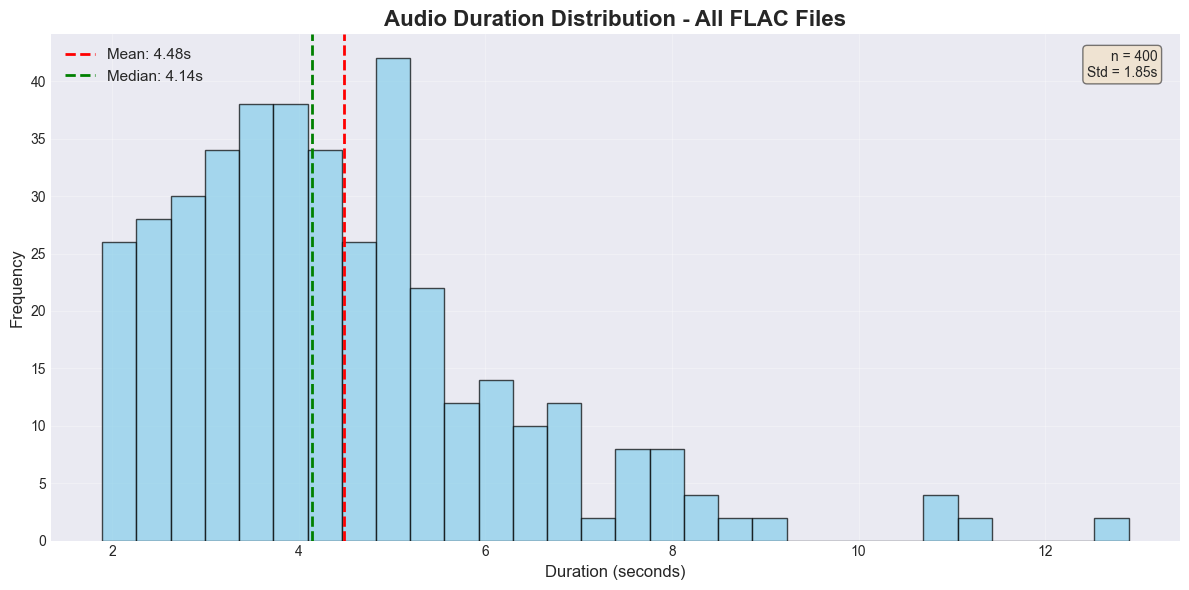

In [10]:
# CELL 10: PLOT 4 - DURATION HISTOGRAM
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING PLOT 4: DURATION HISTOGRAM")
print("=" * 80)

if all_durations:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(all_durations, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_title('Audio Duration Distribution - All FLAC Files', fontsize=16, fontweight='bold')
    ax.set_xlabel('Duration (seconds)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.axvline(np.mean(all_durations), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(all_durations):.2f}s')
    ax.axvline(np.median(all_durations), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(all_durations):.2f}s')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = f'n = {len(all_durations)}\nStd = {np.std(all_durations):.2f}s'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, "04_Duration_Histogram.pdf")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()
else:
    print("⚠ No duration data available")


GENERATING PLOT 7: INTELLIGIBILITY SCORE DISTRIBUTION
✓ Saved: EDA_Plots\07_Intelligibility_Score_Distribution.pdf


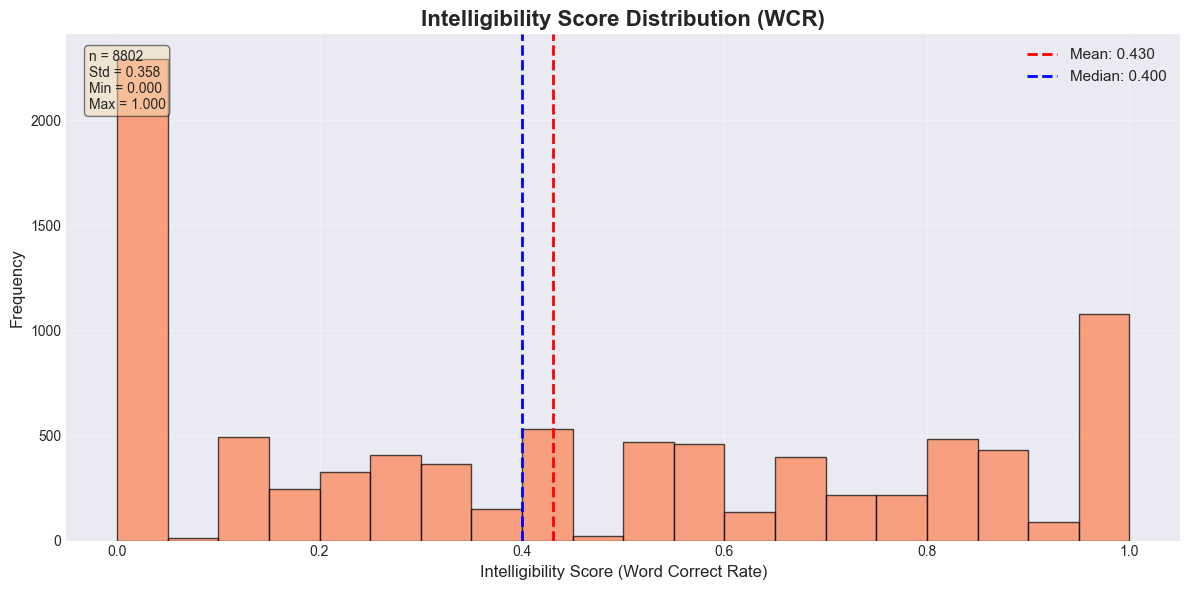

In [15]:
#  CELL 13: PLOT 7 - INTELLIGIBILITY SCORE DISTRIBUTION
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING PLOT 7: INTELLIGIBILITY SCORE DISTRIBUTION")
print("=" * 80)

if metadata_df is not None:
    # Try to find intelligibility score column (various possible names)
    possible_names = ['intelligibility_score', 'intelligibility', 'score', 'wcr', 
                      'word_correct_rate', 'WCR', 'Intelligibility','correctness']
    
    score_column = None
    for name in possible_names:
        if name in metadata_df.columns:
            score_column = name
            break
    
    if score_column:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.hist(metadata_df[score_column], bins=20, edgecolor='black', alpha=0.7, color='coral')
        ax.set_title('Intelligibility Score Distribution (WCR)', fontsize=16, fontweight='bold')
        ax.set_xlabel('Intelligibility Score (Word Correct Rate)', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.axvline(metadata_df[score_column].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {metadata_df[score_column].mean():.3f}')
        ax.axvline(metadata_df[score_column].median(), color='blue', linestyle='--', 
                   linewidth=2, label=f'Median: {metadata_df[score_column].median():.3f}')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Add statistics
        stats_text = (f'n = {len(metadata_df[score_column])}\n'
                     f'Std = {metadata_df[score_column].std():.3f}\n'
                     f'Min = {metadata_df[score_column].min():.3f}\n'
                     f'Max = {metadata_df[score_column].max():.3f}')
        ax.text(0.02, 0.97, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        output_path = os.path.join(OUTPUT_DIR, "07_Intelligibility_Score_Distribution.pdf")
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {output_path}")
        plt.show()
    else:
        print(f"⚠ Intelligibility score column not found in metadata")
        print(f"   Available columns: {metadata_df.columns.tolist()}")
else:
    print("⚠ Metadata not available")



GENERATING PLOT 8: RMS ENERGY COMPARISON
✓ Saved: EDA_Plots\08_RMS_Energy_Comparison.pdf


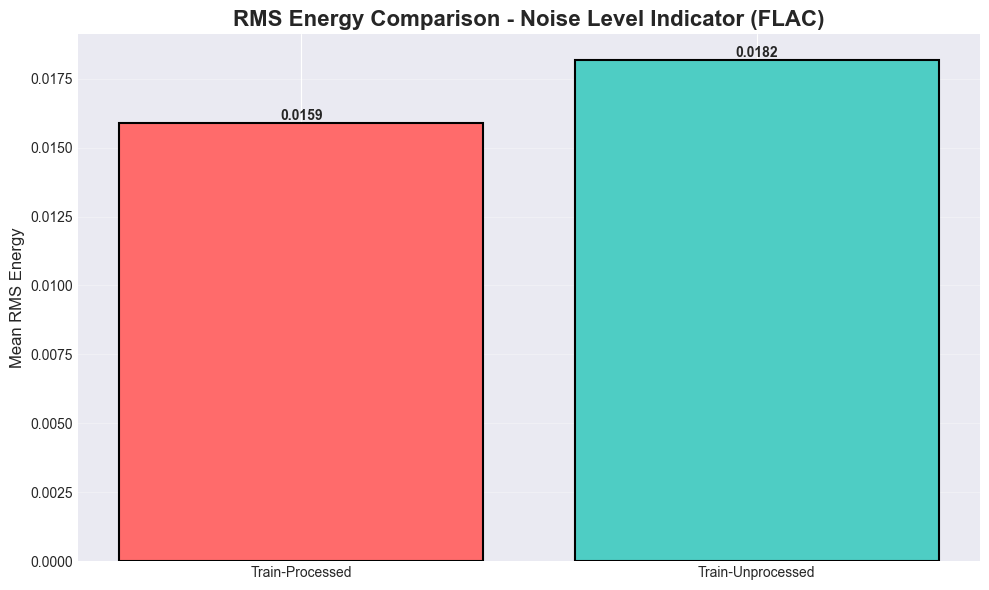

In [16]:
# CELL 14: PLOT 8 - RMS ENERGY COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING PLOT 8: RMS ENERGY COMPARISON")
print("=" * 80)

if audio_stats:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    labels_list = [label for label, _ in audio_stats]
    rms_values = [stats['rms_mean'] for _, stats in audio_stats]
    
    x_pos = np.arange(len(labels_list))
    bars = ax.bar(x_pos, rms_values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels_list, rotation=0)
    ax.set_title('RMS Energy Comparison - Noise Level Indicator (FLAC)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Mean RMS Energy', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, "08_RMS_Energy_Comparison.pdf")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()
else:
    print("⚠ No audio data available for RMS comparison")


In [19]:
# CELL 17: SUMMARY STATISTICS TABLE
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

summary_data = {
    'Metric': [
        'Audio Format',
        'Total Audio Files',
        'Training Files (Processed)',
        'Training Files (Unprocessed)',
        'Validation Files (Processed)',
        'Validation Files (Unprocessed)',
        'Mean Duration (s)',
        'Median Duration (s)',
        'Std Duration (s)',
        'Min Duration (s)',
        'Max Duration (s)',
        'Metadata Format'
    ],
    'Value': [
        'FLAC',
        train_signals_count + train_unproc_count + valid_signals_count + valid_unproc_count,
        train_signals_count,
        train_unproc_count,
        valid_signals_count,
        valid_unproc_count,
        f"{np.mean(all_durations):.2f}" if all_durations else "N/A",
        f"{np.median(all_durations):.2f}" if all_durations else "N/A",
        f"{np.std(all_durations):.2f}" if all_durations else "N/A",
        f"{np.min(all_durations):.2f}" if all_durations else "N/A",
        f"{np.max(all_durations):.2f}" if all_durations else "N/A",
        'JSON'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# Save summary table as CSV
summary_path = os.path.join(OUTPUT_DIR, "Summary_Statistics.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\n✓ Summary statistics saved to: {summary_path}")

# If metadata is available, add metadata summary
if metadata_df is not None:
    print("\n" + "-" * 80)
    print("METADATA SUMMARY:")
    print("-" * 80)
    print(f"Total records: {len(metadata_df)}")
    print(f"Columns: {len(metadata_df.columns)}")
    print("\nColumn Statistics:")
    print(metadata_df.describe())
    
    # Save metadata summary
    metadata_summary_path = os.path.join(OUTPUT_DIR, "Metadata_Summary.csv")
    metadata_df.describe().to_csv(metadata_summary_path)
    print(f"\n✓ Metadata summary saved to: {metadata_summary_path}")

# ============================================================================
# CELL 18: FINAL REPORT
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\n✓ All plots saved in directory: {OUTPUT_DIR}")
print(f"\n📊 Generated Plots (PDF Format):")
print("   01. Waveforms.pdf")
print("   02. Spectrograms.pdf")
print("   03. Mel_Spectrograms.pdf")
print("   04. Duration_Histogram.pdf")
print("   05. Duration_By_Dataset.pdf")
print("   06. File_Count_Distribution.pdf")
print("   07. Intelligibility_Score_Distribution.pdf")
print("   08. RMS_Energy_Comparison.pdf")
print("   09. Zero_Crossing_Rate_Comparison.pdf")
print("   10. Spectral_Centroid_Comparison.pdf")
print(f"\n📄 Summary Files (CSV Format):")
print("   - Summary_Statistics.csv")
if metadata_df is not None:
    print("   - Metadata_Summary.csv")
print(f"\n" + "=" * 80)
print("DATASET INFORMATION:")
print("=" * 80)
print(f"✓ Audio Format: FLAC (lossless compression)")
print(f"✓ Metadata Format: JSON")
print(f"✓ Total Files Analyzed: {len(all_durations) if all_durations else 0}")
print(f"✓ Dataset Splits: Train (Processed & Unprocessed), Validation (Processed & Unprocessed)")
print(f"\n" + "=" * 80)
print("Next Steps:")
print("=" * 80)
print("  1. Review all generated PDF plots in the EDA_Plots folder")
print("  2. Analyze metadata for intelligibility patterns and correlations")
print("  3. Examine hearing loss effects on audio features")
print("  4. Compare processed vs unprocessed audio characteristics")
print("  5. Identify key features for model training")
print("  6. Prepare feature extraction pipeline for model development")
print("=" * 80)


SUMMARY STATISTICS

                         Metric Value
                  Audio Format  FLAC
             Total Audio Files 19954
    Training Files (Processed)  8802
  Training Files (Unprocessed)  8802
  Validation Files (Processed)  1175
Validation Files (Unprocessed)  1175
             Mean Duration (s)  4.48
           Median Duration (s)  4.14
              Std Duration (s)  1.85
              Min Duration (s)  1.89
              Max Duration (s) 12.90
               Metadata Format  JSON

✓ Summary statistics saved to: EDA_Plots\Summary_Statistics.csv

--------------------------------------------------------------------------------
METADATA SUMMARY:
--------------------------------------------------------------------------------
Total records: 8802
Columns: 7

Column Statistics:
           n_words  words_correct  correctness
count  8802.000000    8802.000000  8802.000000
mean      7.316519       3.180754     0.430278
std       1.672484       2.797515     0.357664
min       5.